In [67]:
stock_code = '688793'
split_ratio = 0.7
lambda_value = 0.2  # EWMA 参数
EWMA_threshold = 0.02
initial_trend=0

In [68]:
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [69]:
source_data = ak.stock_zh_a_hist(symbol=stock_code,period="daily",start_date="20240306",end_date='20250306',adjust='')

data = pd.DataFrame()
data['date'] = source_data['日期']
data['price'] = source_data['收盘']
data['volume'] = source_data['成交量']
data.set_index('date', inplace=True)

In [70]:
total_dates = data.index.nunique()
split_index = int(total_dates *split_ratio)
split_date = data.index.unique()[split_index]

train = data[:split_date].copy()
test = data[split_date:].copy()

In [71]:
#基于EWMA的趋势分析法
def calculate_ewma_trend(prices, lambda_value, initial_trend):
    # 初始化 EWMA 趋势序列

    returns = prices.pct_change().dropna()  # 使用 pandas 的 pct_change 计算收益率
    ewma_trend = pd.Series(np.zeros_like(returns), index=returns.index)
    
    ewma_trend.iloc[0] = initial_trend  # 设置初始趋势值
    
    # 递推计算 EWMA 趋势
    for t in range(1, len(returns)):
       # ewma_trend[t] = (1 - lambda_value) * ewma_trend[t-1] + lambda_value * returns[t]
       ewma_trend.iloc[t] = (1 - lambda_value) * ewma_trend.iloc[t-1] + lambda_value * returns.iloc[t]

    return ewma_trend

train['ewma_trend'] = calculate_ewma_trend(train['price'], lambda_value,initial_trend)

train['position'] = np.where(
    train['ewma_trend'] > EWMA_threshold,1,
    np.where(
        train['ewma_trend'] < -EWMA_threshold,-1,
        0
    )
)
train.dropna(inplace=True)

In [72]:
buy = train[train['position'] == 1]
sell = train[train['position'] == -1]

<Axes: title={'center': 'Market Positioning'}, xlabel='date'>

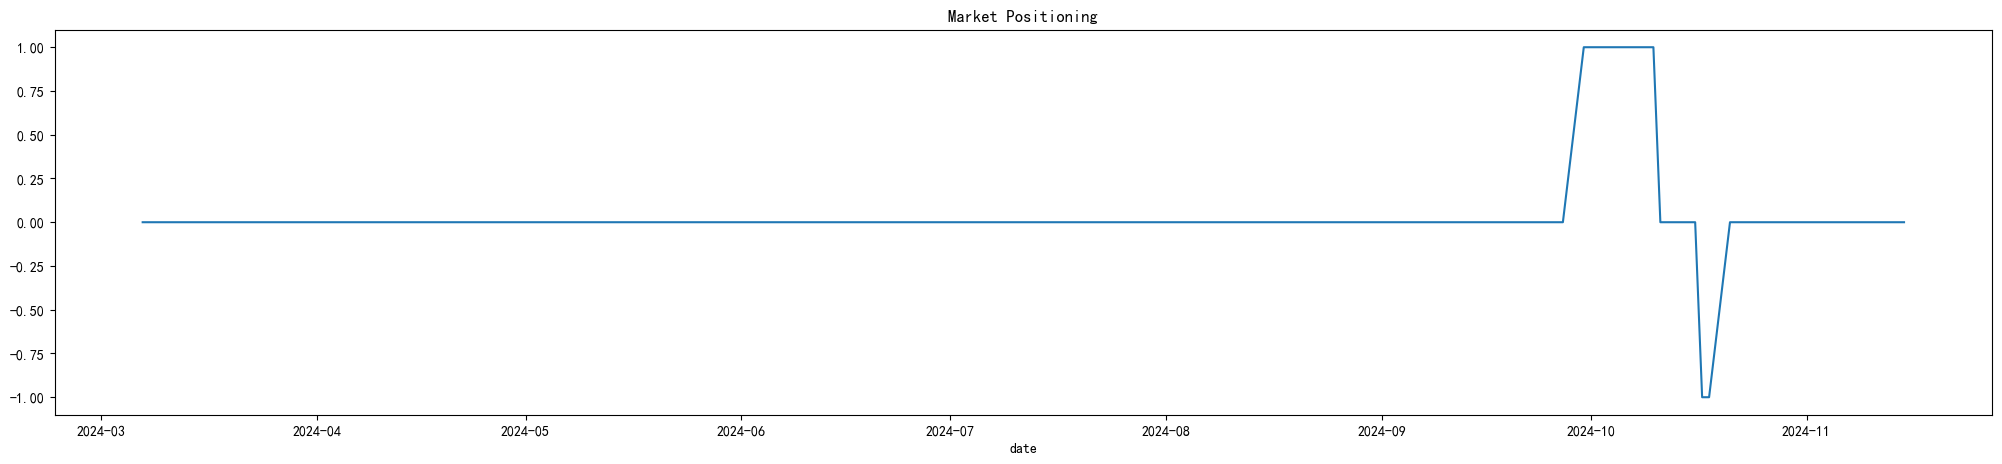

In [73]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

train['position'].plot(ylim=[-1.1,1.1],figsize=(25,5),title='Market Positioning')

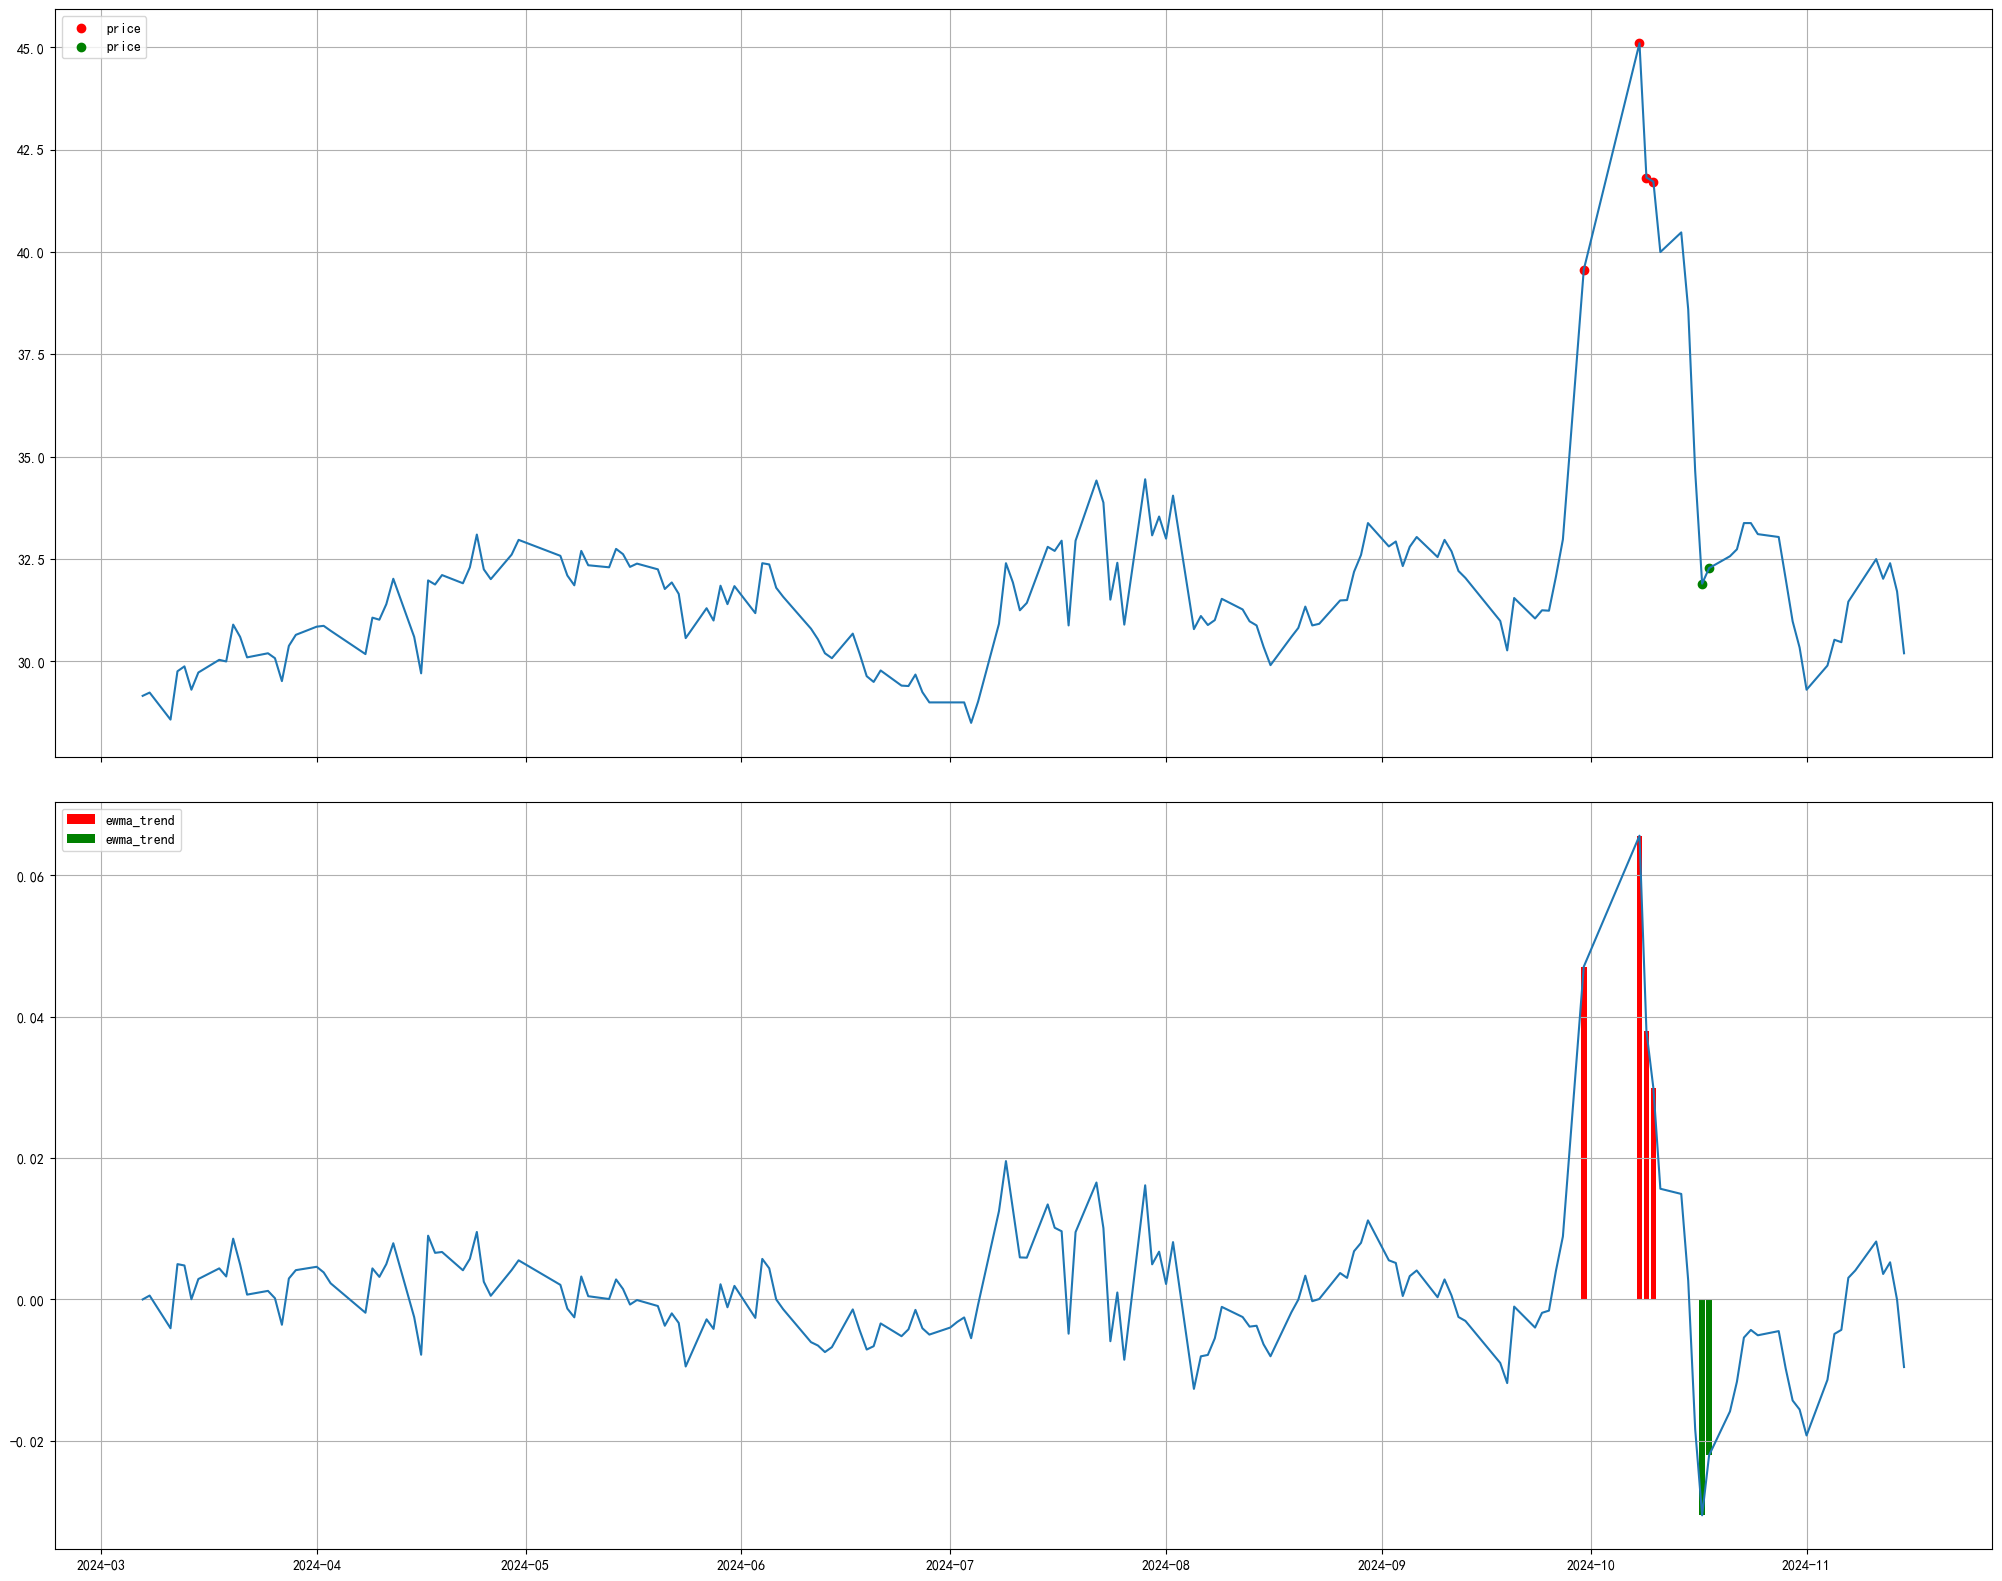

In [74]:
fig, (ax1,ax2) = plt.subplots(2, 1, sharex=True, figsize=(25,20))
plt.rcParams['font.sans-serif'] = ['SimHei']

ax1.plot(train['price'])
ax1.scatter(buy.index, buy['price'], color='red', label='price')
ax1.scatter(sell.index, sell['price'], color='green', label='price')
ax1.set_label('price')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.plot(train['ewma_trend'])
ax2.bar(buy.index, buy['ewma_trend'], color='red', label='ewma_trend')
ax2.bar(sell.index, sell['ewma_trend'], color='green', label='ewma_trend')
ax2.set_label('ewma_trend')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.subplots_adjust(hspace=0.06)

KeyError: 'return'

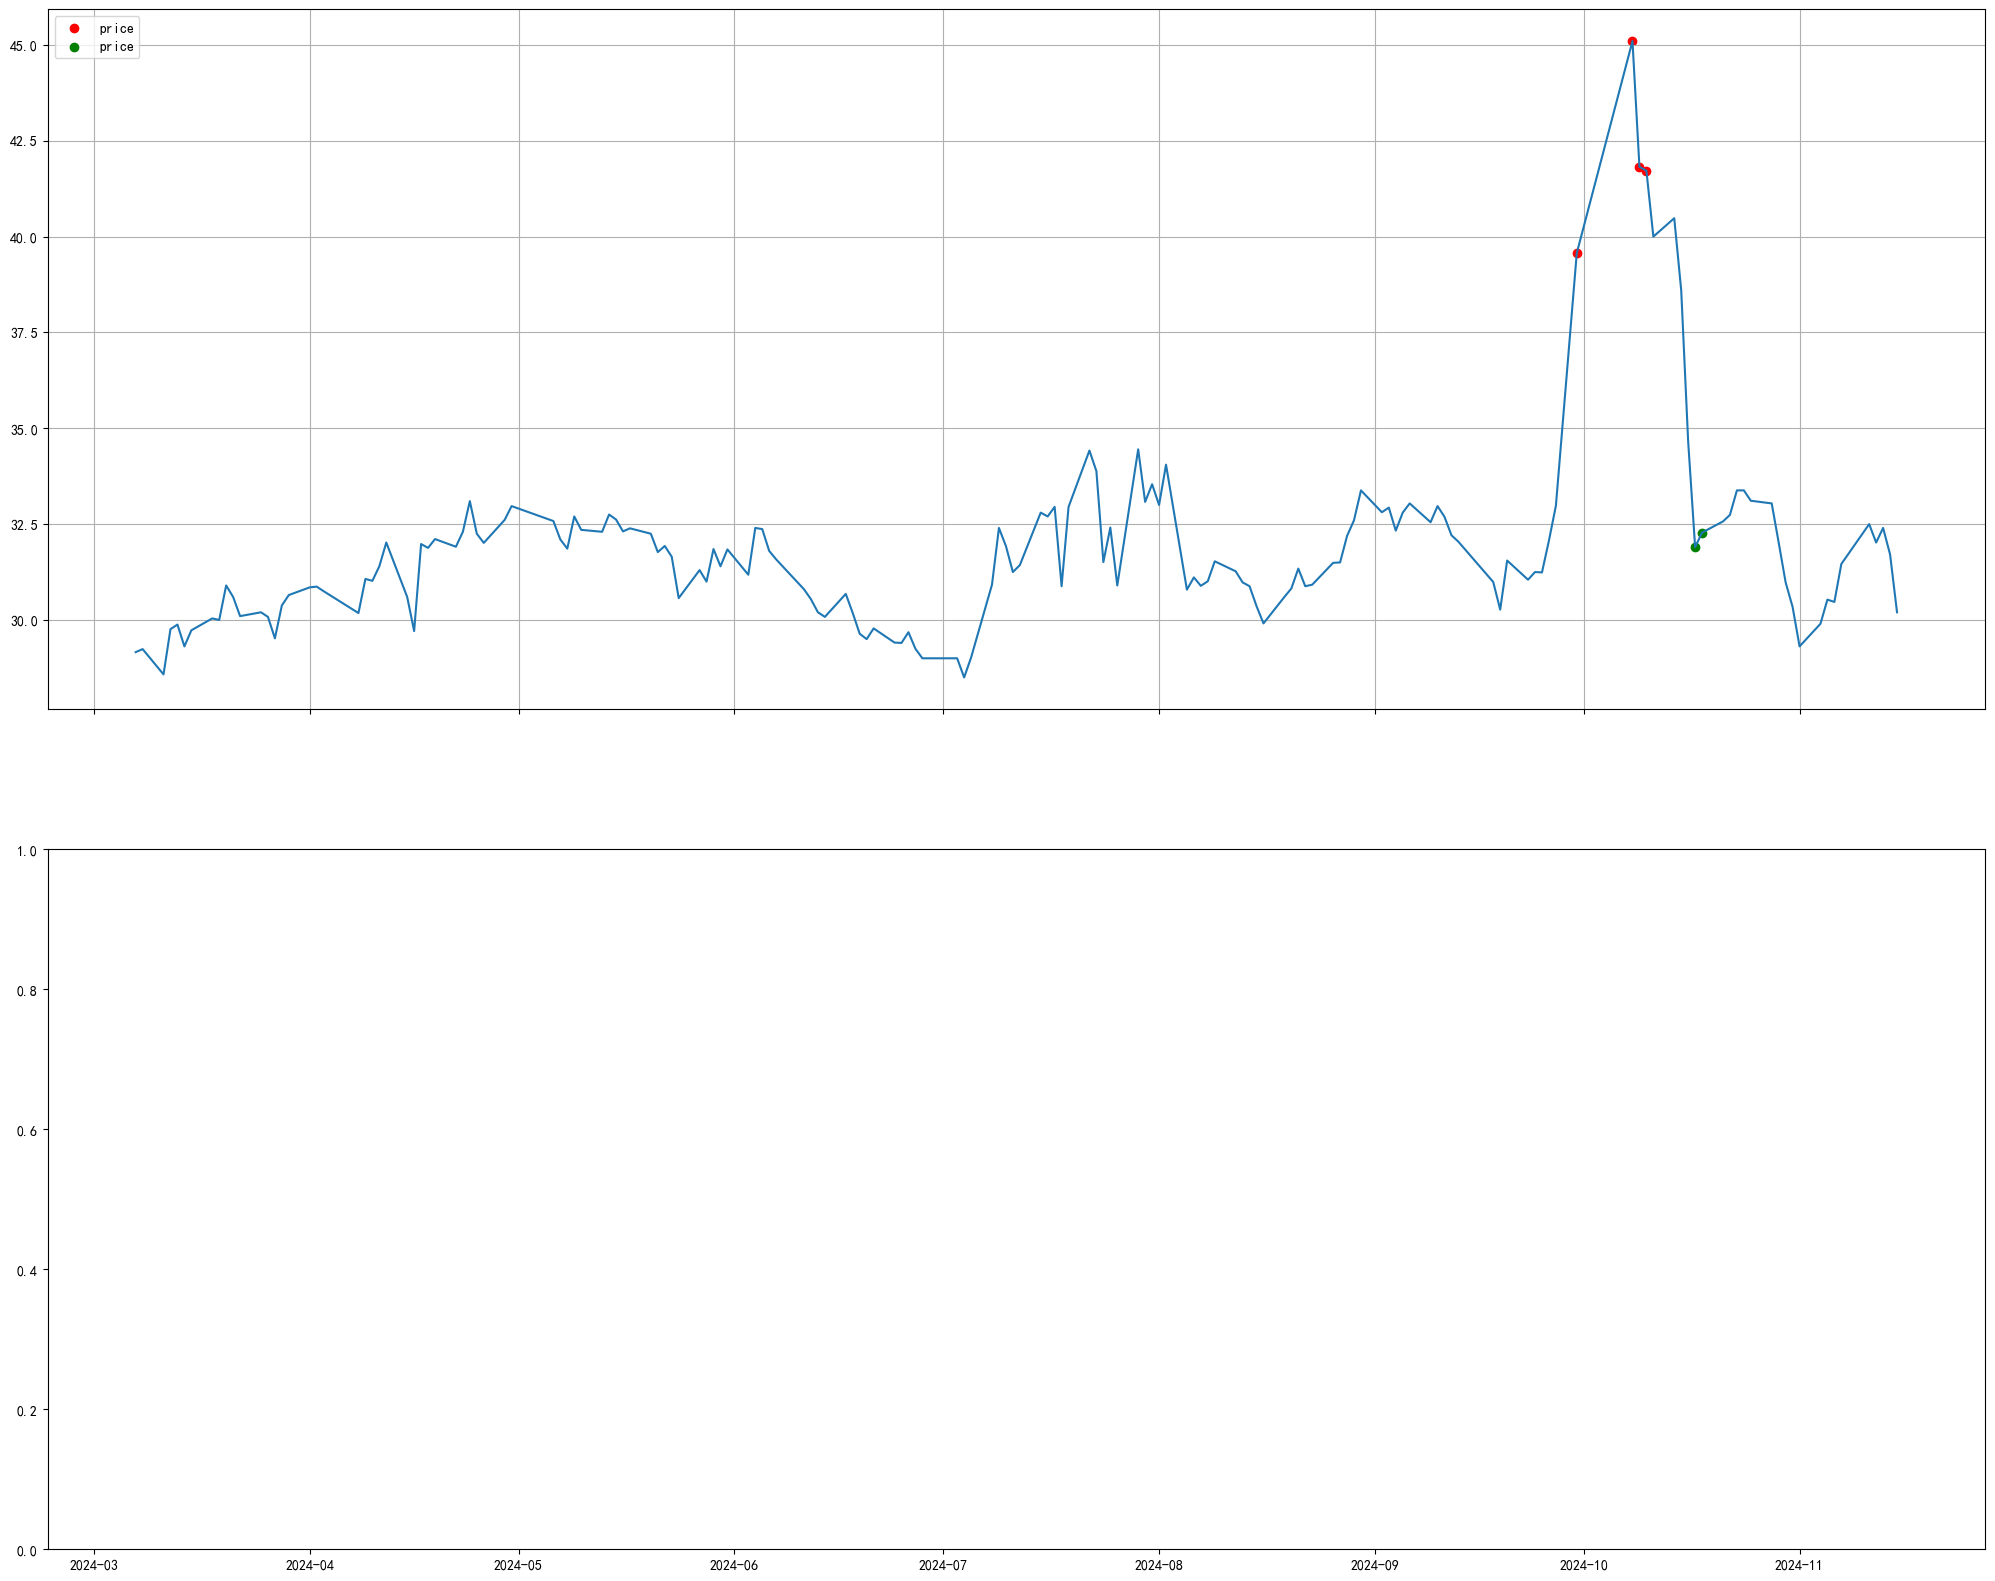

In [75]:
fig, (ax1,ax2) = plt.subplots(2, 1, sharex=True, figsize=(25,20))
plt.rcParams['font.sans-serif'] = ['SimHei']

ax1.plot(train['price'])
ax1.scatter(buy.index, buy['price'], color='red', label='price')
ax1.scatter(sell.index, sell['price'], color='green', label='price')
ax1.set_label('price')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.plot(train['return'])
ax2.bar(buy.index, buy['ewma_trend'], color='red', label='return')
ax2.bar(sell.index, sell['ewma_trend'], color='green', label='return')
ax2.set_label('return')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.subplots_adjust(hspace=0.06)

<Axes: xlabel='date'>

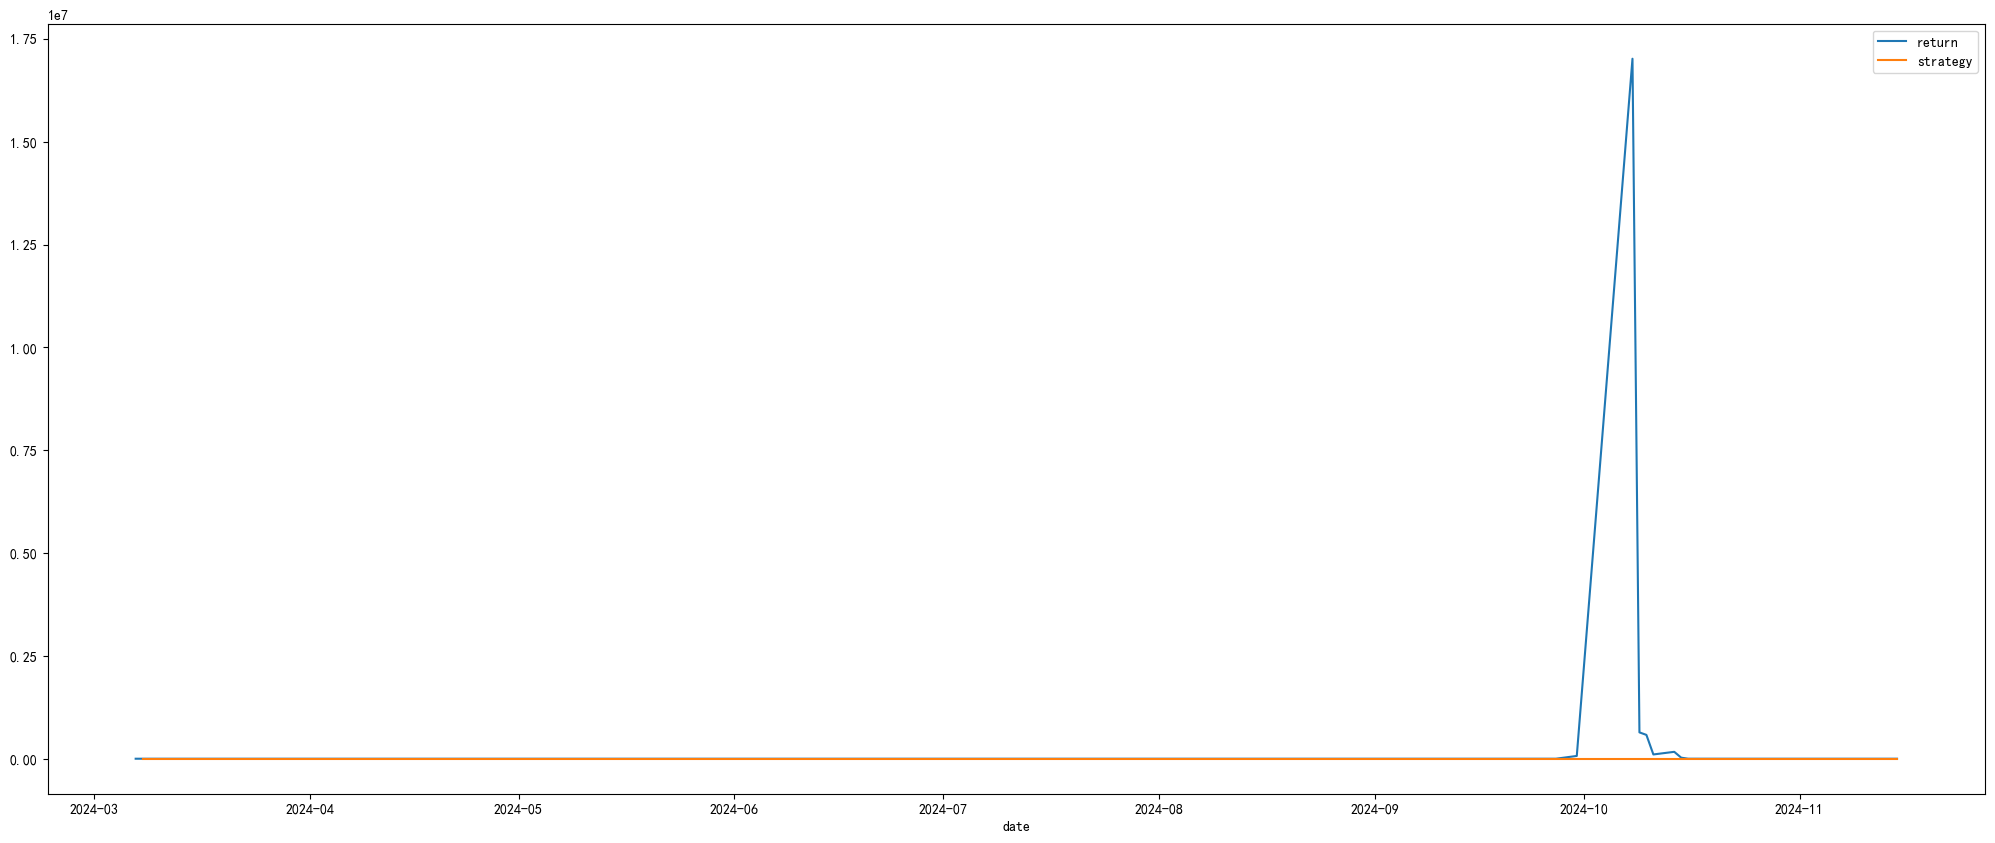

In [ ]:
train['strategy'] = train['position'].shift(1) * train['return']
train[['return','strategy']].sum()

train[['return','strategy']].cumsum().apply(np.exp).plot(figsize=(25,10))

In [ ]:
train[['return','strategy']].mean()

return      0.010355
strategy    0.000000
dtype: float64

In [ ]:
train[['return','strategy']].std()

return      1.136267
strategy    0.000000
dtype: float64

In [ ]:
train[['return','strategy']].mean()/train[['return','strategy']].std()

return      0.009113
strategy         NaN
dtype: float64

0.0

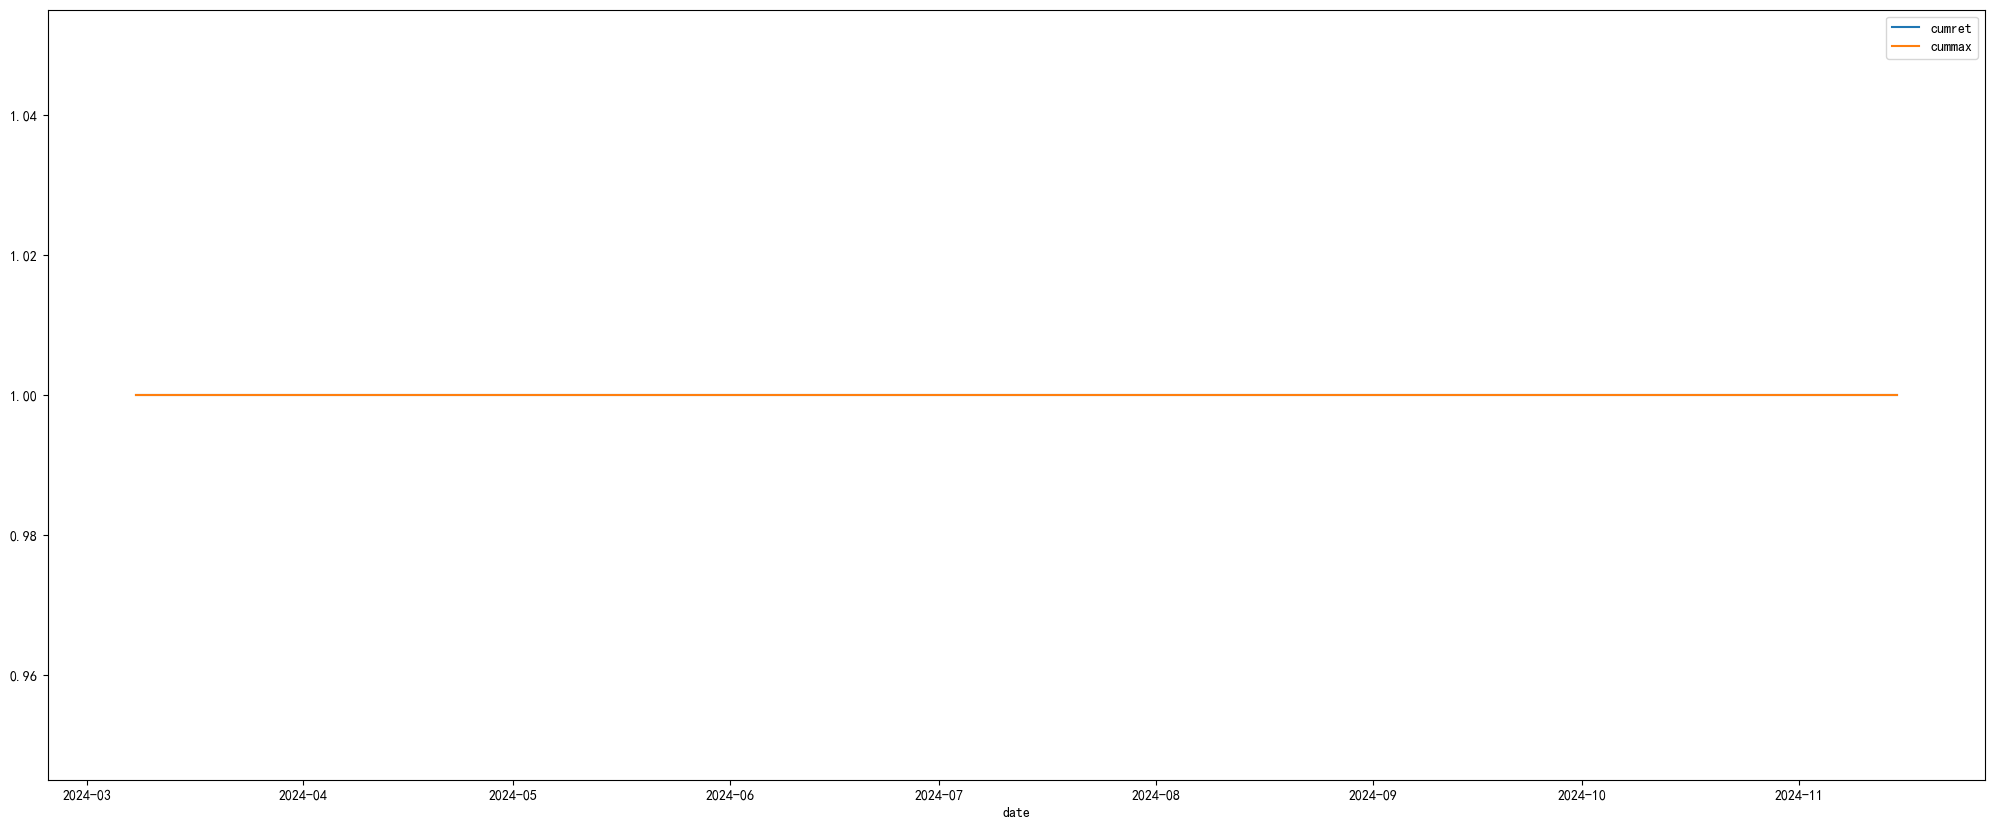

In [ ]:
train['cumret'] = train['strategy'].cumsum().apply(np.exp)
train['cummax']= train['cumret'].cummax()
train[['cumret','cummax']].plot(figsize=(25,10))

traindrawdown = (train['cummax'] - train['cumret'])
traindrawdown.max()